# Práctica implementación y análisis de un sistema de recomendación basado en modelos
## Objetivo

Implementar un filtro colaborativo basado en factorización matricial de bajo rango (se puede utilizar el algoritmo SVD de Surprise). Además, realizarán actividades complementarias para profundizar en la interpretación, evaluación y aplicación de los modelos de recomendación.

# Instalación de todas las librerías necesarias


In [ ]:
# Instalación de todas las librerías necesarias
#!pip install networkx
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
%pip install scikit-learn
%pip install seaborn
%pip install scikit-surprise

In [1]:
# --- Imports y configuración gráfica ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de estilo para gráficos
# Usar las funciones de seaborn para establecer el tema (algunas versiones de matplotlib no exponen 'seaborn' como estilo)
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_context('notebook')

In [2]:
# Carga de DATOS
movies_path = Path('dataset') / 'ml-latest-small' / 'movies.csv'
ratings_path = Path('dataset') / 'ml-latest-small' / 'ratings.csv'

print('Ruta movies:', movies_path)
print('Ruta ratings:', ratings_path)

# Cargar los DataFrames (asumiendo encoding utf-8 estándar)
movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)

print('Cargados: movies ->', movies.shape, ' | ratings ->', ratings.shape)

Ruta movies: dataset\ml-latest-small\movies.csv
Ruta ratings: dataset\ml-latest-small\ratings.csv
Cargados: movies -> (9742, 3)  | ratings -> (100836, 4)


## Instrucciones

1. **Implementación básica del filtro colaborativo. Utilizar el dataset de ratings de MovieLens de 100k ratings (recommended for education and development, small)**


Implementamos filtrado colaborativo con MovieLens 100K usando **surprise.SVD**: cargamos ratings, preparamos el dataset para Surprise, evaluamos con validación cruzada (RMSE/MAE) y entrenamos el modelo final para predecir. 

¿Qué es el filtro colaborativo (CF)?  “usuarios parecidos puntúan parecido”.
Solo usaremos interacciones (userId, movieId, rating); no usaremos géneros.<br><br>

*Realizamos una Evaluación (validación cruzada)* para promediar el RMSE y MAE 
 Esto lo hacemos haciendo predicciónes de ratings de pares (usuario,película) que se reservaron para test y comparas predicho vs real. Con esas diferencias se calcula MAE/RMSE.

cross_validate(SVD(...), data, measures=['RMSE','MAE'], cv=5)
 - *Partición (k-fold o train/test): separas un conjunto de ratings reales para test.*
    - RMSE: error cuadrático medio (penaliza a fallos más grandes).
    - MAE: error absoluto medio (cuantos puntos se equivoca).
     - Nos da rendimiento “out-of-sample” antes del entrenamiento final.

*Entrenamiento final:* Entrenamos con todos los datos para luego recomendar:
- trainset = data.build_full_trainset()
- modelo = SVD(random_state=42).fit(trainset)
    
*Finalmente hacemos una predicición de la puntuación de un usuario*




In [3]:
from surprise import Dataset, Reader, SVD
#Reader : Define el rango de ratings y el orden de las columnas al cargar desde pandas.
#Clave: Reader(rating_scale=(min_rating, max_rating)).
#Dataset : Crea datasets de Surprise desde un DataFrame:
# SVD : Implementa factorización matricial con sesgos (μ + bᵤ + bᵢ + pᵤ·qᵢ).

from surprise.model_selection import cross_validate
 #validación cruzada k-fold con tu algo (p. ej., SVD) y un Dataset de Surprise: 
 # entrena y evalúa en k particiones, y te devuelve métricas por fold (RMSE/MAE, tiempos),
 # para que tengas un rendimiento promedio fuera de muestra.

In [7]:
# Prepara los datos para Surprise

# Surprise mapea "raw ids" tal cual; si entrenas con int y predices con str, no coinciden.
ratings = ratings.copy()
ratings["userId"] = ratings["userId"].astype(str)   # lo dejamos como str para evitar confusiones
ratings["movieId"] = ratings["movieId"].astype(str) # lo dejamos como str para evitar confusiones
ratings["rating"] = ratings["rating"].astype(float) # para evitar errores


#Columnas fichero ratings: userId, movieId, rating, timestamp
# reader almacena el rango de ratings

# Rango de ratings
rmin, rmax = float(ratings["rating"].min()), float(ratings["rating"].max())
# Es  (1,5); pero usamos el real por si difiere.
reader = Reader(rating_scale=(rmin, rmax))  # espacio de ratings

# data almacena el dataset en formato Surprise , con el rango de datos definido en reader
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Crea el modelo SVD
modelo = SVD(random_state=42)
#radmon_state es la semilla para reproducibilidad



# 1-Divide el dataset en cv folds (k particiones).
# 2-Entrena el algoritmo en k-1 folds y evalúa en el fold restante, repite k veces.
# 3-Devuelve un dict con arrays por métrica: test_rmse, test_mae
# Evalúa el modelo con validación cruzada (5 folds)
results = cross_validate(modelo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)
# Parámetros:
# modelo, → instancia de surprise.SVD (u otro algoritmo) ya creada, pero sin entrenar.
# data, → Dataset de Surprise (no un DataFrame).
# measures=['RMSE','MAE'], → métricas a calcular (mayúsculas).
# cv=5, → k-fold con k=5 particiones.
# verbose=True → imprime líneas por cada fold (fit/test time y métricas).


# RMSE (Root Mean Squared Error) mide cuánto se equivoca tu modelo de media, penalizando más los errores grandes. Más bajo = mejor.
# MAE (Mean Absolute Error) es el promedio del error absoluto. Más bajo = mejor. Penaliza todos los errores linealmente (menos severo con outliers que RMSE).
# fit_time = segundos que tarda entrenar el modelo en cada fold.
# test_time = segundos que tarda en predecir + evaluar en el fold de test.


print()
print("Resultados de validación cruzada SVD:")
print("RMSE promedio:", results['test_rmse'].mean())
print("MAE promedio:", results['test_mae'].mean())

# Crea el Trainset interno que Surprise necesita para entrenar: 
# mapea tus IDs “raw” a índices contiguos (inner ids), calcula la media global y 
# construye las estructuras usuario↔ítems vistos.
trainset = data.build_full_trainset()

#Entrena el SVD usando todos los ratings disponibles preparados por trainset.
modelo.fit(trainset)

# Ejemplo: predecir el rating del usuario 1 para la película 1
uid = str(1)  # userId como string
iid = str(1)  # movieId como string
pred = modelo.predict(uid, iid)
print()
print('-----------------------------------------------------')
print(f"Predicción para userId={uid}, movieId={iid}: {pred.est:.2f}")



Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8733  0.8724  0.8743  0.8744  0.8750  0.8738  0.0009  
MAE (testset)     0.6698  0.6713  0.6725  0.6732  0.6733  0.6720  0.0013  
Fit time          0.82    0.82    0.71    0.84    0.68    0.77    0.07    
Test time         0.07    0.18    0.06    0.17    0.05    0.11    0.06    

Resultados de validación cruzada SVD:
RMSE promedio: 0.8738403178194478
MAE promedio: 0.6719999342733279

-----------------------------------------------------
Predicción para userId=1, movieId=1: 4.80



2. Añadir uno o varios usuarios que representen a los miembros del equipo de prácticas (con ratings a un subconjunto de las películas del dataset), ajustar el filtro y mostrar las 10 mejores recomendaciones que proporciona a cada usuario añadido.



Creamos usuarios similares (Angel y Rubén), les damos ratings a unas cuantas pelis, y pedimos Top-10 recomendaciones con modelo.predict(uid,iid) sobre pelis que no han puntuado.<br>
Es un CF con SVD = Filtrado colaborativo usando factorización matricial, se  entrena con los ratings observados minimizando el error (SGD + regularización).<br>
Filtrado colaborativo basado en modelos (Matrix Factorization, SVD): aprende sesgos 
𝑏𝑢 ,𝑏i y factores latentes 𝑝𝑢 , 𝑞𝑖 <br>
​
![Formula SVD con Sesgos](sesgos.png)

1- Funcion para buscar el Movi ID de la pelicula<br>
2- Construimos los nuevos perdiles<br>
3- Es necsario entrenar de nuevo, porque tenemos nuevos ratings de los usuarios <br>
4- Con todas las peliculas puntuadas , le quito las ya puntuadas por el usuario,  muestreo 1000 aleatorias.<br>
5- Para cada movieId en la muestra, llamo a modelo.predict(uid, iid), extraemos pred.est y se guarda (título, score, movieId).<br>
6- Se crea ranking.<br>


In [ ]:

print("\n3. AÑADIENDO NUEVOS USUARIOS...")
# Función para encontrar el movieId dado el título de la película
def find_movie_id(movie_title, movies_df):
    # Buscar coincidencias exactas o parciales en el título
    movie = movies_df[movies_df['title'].str.contains(movie_title, case=False, na=False)]
    if len(movie) > 0:
    # Devuelve el movieId encontrado
        return movie.iloc[0]['movieId']
    
    return None

# Crear nuevos usuarios en un array
new_users_ratings = []

# Angel
user1_ratings = [
    ('Toy Story', 5),
    ('Star Wars: Episode IV - A New Hope', 5),
    ('Terminator 2: Judgment Day', 4),
    ('Pulp Fiction', 3),
    ('Forrest Gump', 2),
    ('Silence of the Lambs', 4)
]

# Ruben 
user2_ratings = [
    ('Toy Story', 3),
    ('Forrest Gump', 5),
    ('Shawshank Redemption', 5),
    ('Star Wars: Episode IV - A New Hope', 2),
    ('Pretty Woman', 4),
    ('Braveheart', 4)
]

def add_user_ratings(user_id, user_ratings, new_users_ratings, movies_df):
    # Añade ratings de un nuevo usuario a la lista movies_df que contiene los ratings.
    for movie_title, rating in user_ratings:
        movie_id = find_movie_id(movie_title, movies_df)
        if movie_id:
            new_users_ratings.append({
                'userId': user_id,
                'movieId': movie_id,
                'rating': rating,
                'title': movie_title
            })
            print(f"   {movie_title} -> ID: {movie_id}, Rating: {rating}")
        else:
            print(f"   Película no encontrada: {movie_title}")

# Usar IDs que no existan (mayores a 610)
print("Añadiendo usuario 1000:")
#Añadimos los ratings del usuario 1000 al dataset de movies
add_user_ratings(1000, user1_ratings, new_users_ratings, movies)

print("\nAñadiendo usuario 1001:")
add_user_ratings(1001, user2_ratings, new_users_ratings, movies)

print(f"\nSe añadieron {len(new_users_ratings)} ratings de nuevos usuarios")

# =============== (REENTRENO SVD CON NUEVOS USUARIOS) ===============
# Para que Surprise aprenda p_u y b_u de los nuevos usuarios; evitar empezar de 0
new_users_df = pd.DataFrame(new_users_ratings, columns=['userId','movieId','rating','title'])

# Normalizar tipos
ratings_ext = ratings.copy()
ratings_ext['userId']  = ratings_ext['userId'].astype(str)
ratings_ext['movieId'] = ratings_ext['movieId'].astype(str)
ratings_ext['rating']  = ratings_ext['rating'].astype(float)

new_users_df_norm = new_users_df[['userId','movieId','rating']].copy()
new_users_df_norm['userId']  = new_users_df_norm['userId'].astype(str)
new_users_df_norm['movieId'] = new_users_df_norm['movieId'].astype(str)
new_users_df_norm['rating']  = new_users_df_norm['rating'].astype(float)

# Concatenar con los ratings existentes
ratings_ext = pd.concat([ratings_ext[['userId','movieId','rating']], new_users_df_norm], ignore_index=True)

# Reentrenar
reader = Reader(rating_scale=(1, 5))
data_ext = Dataset.load_from_df(ratings_ext[['userId','movieId','rating']], reader)
trainset_ext = data_ext.build_full_trainset()
modelo = SVD(random_state=42).fit(trainset_ext)
# ================================================================

#  GENERAR RECOMENDACIONES

print("\n4. GENERANDO RECOMENDACIONES...")

def get_top_recommendations(user_id, modelo, movies_df, n_recommendations=10):
    # Genera las mejores recomendaciones para un usuario
    #Cargamos todas las peliculas
    all_movies = set(movies_df['movieId'])
    
    # Obtener películas ya calificadas por el usuario
    rated_movies = set([r['movieId'] for r in new_users_ratings if r['userId'] == user_id])
    # Obtener películas no calificadas
    unrated_movies = all_movies - rated_movies
    
    #Comprobación de errroes
    if len(unrated_movies) == 0:
        return []
    
    # Predecir ratings para películas no calificadas (muestrear para eficiencia
    # Tomamos una muestra de 1000 películas no calificadas o menos si no hay tantas
    sample_size = min(1000, len(unrated_movies))
    # La guardamos en una muestra aleatoria
    unrated_sample = np.random.choice(list(unrated_movies), sample_size, replace=False)
    
    predictions = []
    # Vamos a predecir el rating para cada película en la muestra (que son 10)
    for movie_id in unrated_sample:
        try:
            # La predicción del modelo SVD para la pelicula escogida al azar.
            pred = modelo.predict(user_id, movie_id)
            est = pred.est  # usar la estimación como número (float)
            movie_title = movies_df[movies_df['movieId'] == movie_id]['title'].iloc[0]
            # guardamos la predicción
            predictions.append((movie_title, est, movie_id))
        except Exception:
            continue
    
    # Ordenar por rating predicho (est) y devolver las mejores
    predictions.sort(key=lambda x: x[1], reverse=True)
    #volvemos hasta obtener n_recommendations
    return predictions[:n_recommendations]

# Generar recomendaciones para cada nuevo usuario
for user_id in [1000, 1001]:
    print(f"\nTOP 10 RECOMENDACIONES PARA USUARIO {user_id}:")
    
    # Mostrar películas calificadas
    user_ratings = [r for r in new_users_ratings if r['userId'] == user_id]
    print(f"Películas calificadas por el usuario:")
    for rating in user_ratings:
        print(f"  - {rating['title']}: {rating['rating']}")
    
    # Generar recomendaciones
    recommendations = get_top_recommendations(user_id, modelo, movies)
    
    print(f"\nRecomendaciones:")
    for i, (title, score, movie_id) in enumerate(recommendations, 1):
        # score es un float (est), por lo que se puede formatear con .3f sin error
        print(f"  {i:2d}. {title} (score: {score:.3f})")


3. AÑADIENDO NUEVOS USUARIOS...
Añadiendo usuario 1000:
   Toy Story -> ID: 1, Rating: 5
   Star Wars: Episode IV - A New Hope -> ID: 260, Rating: 5
   Terminator 2: Judgment Day -> ID: 589, Rating: 4
   Pulp Fiction -> ID: 296, Rating: 3
   Forrest Gump -> ID: 356, Rating: 2
   Silence of the Lambs -> ID: 593, Rating: 4

Añadiendo usuario 1001:
   Toy Story -> ID: 1, Rating: 3
   Forrest Gump -> ID: 356, Rating: 5
   Shawshank Redemption -> ID: 318, Rating: 5
   Star Wars: Episode IV - A New Hope -> ID: 260, Rating: 2
   Pretty Woman -> ID: 597, Rating: 4
   Braveheart -> ID: 110, Rating: 4

Se añadieron 12 ratings de nuevos usuarios

4. GENERANDO RECOMENDACIONES...

TOP 10 RECOMENDACIONES PARA USUARIO 1000:
Películas calificadas por el usuario:
  - Toy Story: 5
  - Star Wars: Episode IV - A New Hope: 5
  - Terminator 2: Judgment Day: 4
  - Pulp Fiction: 3
  - Forrest Gump: 2
  - Silence of the Lambs: 4

Recomendaciones:
   1. Dead of Night (1945) (score: 3.502)
   2. THX 1138 (1971)

3. Analizar los sesgos estimados en el modelo ¿Qué usuarios tienden a puntuar más bajo o más alto? ¿Qué películas tienden a tener más ratings?


Se va utilizar la clase surprise, vamos a calcular los sesgos de .bu y .bi y mapearlos con trainset. Para usuarios que puntuan alto/bajo , y películas con sesgo algto/bajo. 

Modelo SVD (con sesgos):

![Formula SVD con Sesgos](sesgos.png)

Vectores de sesgos aprendidos:
    bu = bias por usuario 
    bi = bias por ítem 
Se indexan con ids internos (no los “raw”),hay que mapear con trainset.
    <br>μ: media global de las notas (en Surprise: trainset.global_mean).
    <br>bu: tendencia del usuario u (si puntúa alto/bajo). -> modelo.bu[inner_u]
    <br>bi: tendencia de la película i (si suele gustar más/menos). → algo.bi[inner_i]
    <br>pu, qu : factores latentes. -> modelo.pu[inner_u], modelo.qi[inner_i]
<br>
<br>*bu = bias user : si puntúa más alto (>0) o bajo ('<'0 ) que la media.
<br>*bi = bias item : si la peli recibe notas más altas (>0) o más bajas ('<' 0) que la media.
<br>Además, para “¿qué pelis tienen más ratings?” miramos el conteo de votos por movieId.
<br>
<br>Los sesgos bu (usuario) y bi (ítem) están en arrays indexados por IDs internos de Surprise. Para leer el sesgo de un userId/movieId “raw”, primero conviertes a inner id con trainset.to_inner_uid/iid, luego accedes a modelo.bu[inner_u] y modelo.bi[inner_i].





In [7]:
# NO necesario si ya importado.
from __future__ import annotations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NO NECESARIO SI YA ESTA ENTRENADO. tienes entrenado:
# Crea el Trainset interno que Surprise necesita para entrenar: 
# mapea tus IDs “raw” a índices contiguos (inner ids), calcula la media global y construye las estructuras usuario↔ítems vistos.
# trainset = data.build_full_trainset()
#Entrena el SVD usando todos los ratings disponibles preparados por trainset.
# modelo = SVD(random_state=42).fit(trainset)


Sesgos de usuarios
Sesgo medio usuarios: -0.0032
Usuario con sesgo más positivo: 43 (bias 1.1526)
Usuario con sesgo más negativo: 442 (bias -1.8102)

 Películas con mayor sesgo positivo
  - Shawshank Redemption, The (1994): 0.9071
  - Lawrence of Arabia (1962): 0.8278
  - Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964): 0.8177
  - Philadelphia Story, The (1940): 0.7876
  - Streetcar Named Desire, A (1951): 0.7779

 Películas con mayor sesgo negativo
  - Speed 2: Cruise Control (1997): -1.3132
  - Battlefield Earth (2000): -1.2386
  - Anaconda (1997): -1.1657
  - Spice World (1997): -1.1629
  - Godzilla (1998): -1.1548

 Películas más populares (más ratings)
  - Forrest Gump (1994): 329 ratings, promedio 4.164
  - Shawshank Redemption, The (1994): 317 ratings, promedio 4.429
  - Pulp Fiction (1994): 307 ratings, promedio 4.197
  - Silence of the Lambs, The (1991): 279 ratings, promedio 4.161
  - Matrix, The (1999): 278 ratings, promedio 4.192

 El histograma

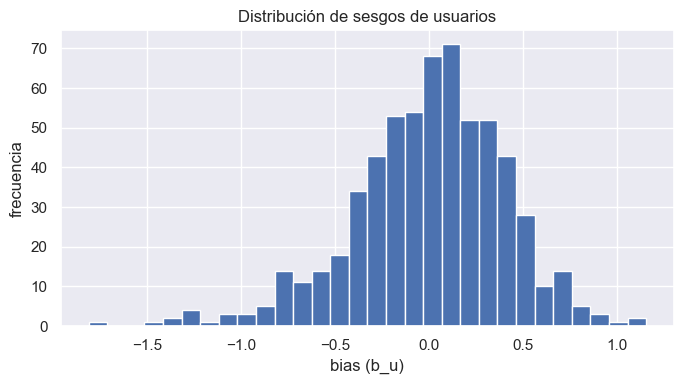

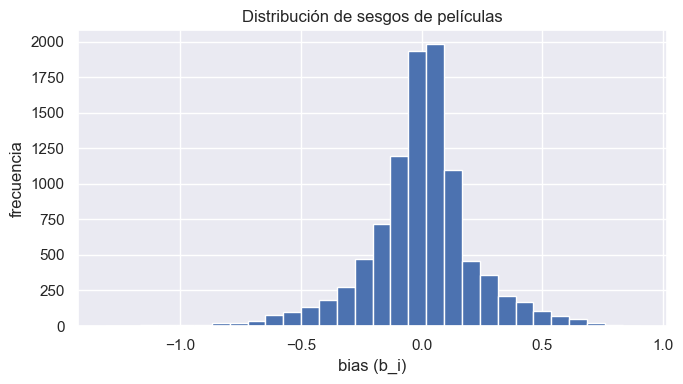

In [ ]:
#  Normalización de los datos.

#Si hace falta renombrar campos:
#ratings = ratings.rename(columns={'user_id':'userId', 'item_id':'movieId'})
ratings['userId']  = ratings['userId'].astype(str)
ratings['movieId'] = ratings['movieId'].astype(str)
# La puntuación como float.
ratings['rating']  = ratings['rating'].astype(float)

#Si hace falta renombrar campos:
#movies_df = movies.rename(columns={'item_id':'movieId'})[['movieId','title']].copy()
movies_df = movies.copy()
movies_df['movieId'] = movies_df['movieId'].astype(str)

# Calculo de  Sesgos de usuario (b_u) ---
# Surprise usa ids internos; mapeamos de inner->raw para emparejar
user_biases = []
for inner_u in range(trainset.n_users):
    # Convertir indice interno inner id de sunrise a raw id (userId original)
    raw_u = trainset.to_raw_uid(inner_u)
    #bu es la tendencia del usuario (positivo = puntúa alto)
    # Calculamos Sesgo
    bu = float(modelo.bu[inner_u])     
    # Añadimos el sesgo a la lista con el usuario correspondiente.
    user_biases.append({'userId': raw_u, 'bias': bu})
# Lo pasamos a panda para trabajar mejor    
user_biases_df = pd.DataFrame(user_biases)

print("\nSesgos de usuarios")
# Referencia global del sesgo, el sesgo medio
print(f"Sesgo medio usuarios: {user_biases_df['bias'].mean():.4f}")

# Localizar extremos para interpretar quién sobre/infra-puntúa de forma sistemática
max_u = user_biases_df.loc[user_biases_df['bias'].idxmax()]
min_u = user_biases_df.loc[user_biases_df['bias'].idxmin()]
# Localizamos usuarios con sesgo más positivo y negativo
print(f"Usuario con sesgo más positivo: {max_u['userId']} (bias {max_u['bias']:.4f})")
print(f"Usuario con sesgo más negativo: {min_u['userId']} (bias {min_u['bias']:.4f})")

# Sesgos de ítem (b_i) 
# Para guardar los biases de ítem
item_biases = []

# bu/bi/pu/qi están indexados por ids internos en trainset
for inner_i in range(trainset.n_items):
    #convertimos id interno -> id "real" para poder unir con catálogo/títulos
    raw_i = trainset.to_raw_iid(inner_i)
    bi = float(modelo.bi[inner_i])  # tendencia propia del ítem tras quitar μ y b_u; >0 suele gustar más
    item_biases.append({'movieId': raw_i, 'bias': bi})

#unimos sesgos con títulos; left para no perder ítems aunque falte el título
movie_biases_df = pd.DataFrame(item_biases).merge(movies_df, on='movieId', how='left')

print("\n Películas con mayor sesgo positivo")
# Devuelve los mas positivos
for _, r in movie_biases_df.nlargest(5, 'bias')[['title','bias']].iterrows():
    print(f"  - {r['title']}: {r['bias']:.4f}")

# Devuelve los mas negativos
print("\n Películas con mayor sesgo negativo")
for _, r in movie_biases_df.nsmallest(5, 'bias')[['title','bias']].iterrows():
    print(f"  - {r['title']}: {r['bias']:.4f}")

# Popularidad de películas (nº ratings y media)
movie_popularity = (
    # Agrupamos por película y operamos solo sobre la columna rating
    ratings.groupby('movieId')['rating']
    #  dos agregados útiles: cuántos ratings y su media
    .agg(rating_count='count', rating_mean='mean')
    #redondeo ligero para impresión/lectura (no cambia orden)
    .round(3)
    # pasamos de índice por movieId a columna normal para poder mergear
    .reset_index()
    # añadimos 'title' (catálogo); 'left' conserva todas las pelis del agg
    .merge(movies_df, on='movieId', how='left')
)
print("\n Películas más populares (más ratings)")
for _, r in movie_popularity.nlargest(5, 'rating_count')[['title','rating_count','rating_mean']].iterrows():
    print(f"  - {r['title']}: {r['rating_count']} ratings, promedio {r['rating_mean']:.3f}")

# Histogramas (uno por figura; simple) ---
print("\n --------------------------------------------------------------------------------------------")
print("\n El histograma de sesgos de usuario (bᵤ) muestra cuántos usuarios caen en cada rango de sesgo.")
plt.figure(figsize=(7,4))
# 30 bins ≈ buen compromiso; no fijar color para no sesgar lectura
plt.hist(user_biases_df['bias'], bins=30)   # why: no fijar colores para mantener neutralidad
plt.title('Distribución de sesgos de usuarios')
# eje X = sesgo de usuario
plt.xlabel('bias (b_u)')
# conteo de usuarios por bin 
plt.ylabel('frecuencia')
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
# misma granularidad para comparar visualmente con b_u
plt.hist(movie_biases_df['bias'], bins=30)
plt.title('Distribución de sesgos de películas')
 # eje X = sesgo de ítem (película)
plt.xlabel('bias (b_i)')
# conteo de películas por bin
plt.ylabel('frecuencia')
plt.tight_layout(); plt.show()


4. **Análisis en el espacio latente a partir de los vectores de características latentes de usuarios y películas. Calcular las 10 películas más próximas a una dada, por ejemplo, “Toy Story”**



Analizamos el espacio latente con Surprise SVD

![Formula SVD con Sesgos](sesgos.png)

Usamos Qᵢ porque son los vectores latentes de las películas. La proximidad entre películas debe medirse en el espacio de ítems; para usuarios sería Pᵤ.

Por qué Q (ítems) para similitud entre películas
- Modelo SVD con sesgos: 
        pu  = factores del usuario (gustos).
        qi = factores del ítem (características de la película).

- Similitud de películas ⇒ comparamos características de películas ⇒ usamos q𝑖
- Similitud de usuarios ⇒ comparamos gustos de usuarios ⇒ usamos 𝑝𝑢
- Los sesgos 𝑏𝑢,𝑏𝑖  no representan rasgos comparables; se excluyen de la similitud.
- Coseno es habitual (comparo vectores): invariante a escala y capta orientación en el espacio latente (qué tipo de película es). 
        <br>Como de alineado está el vector latente de la peli objetivo con cada vector de peli en Q. 
        <br>1 = muy parecidas
        <br>0 = sin relación
        <br>-1 = opuestas. 
        <br>Usamos coseno porque mide dirección (patrón de rasgos) y no la magnitud.

In [14]:
# NO necesario si ya importado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity    # métrica estándar en espacios latentes
from sklearn.decomposition import PCA                     # reducir a 2D para visualizar

# PRE: existen:
# - modelo: SVD ya entrenado con modelo.fit(trainset)
# - trainset: objeto Trainset usado para el fit
# - movies_df: DataFrame con ['movieId','title'] (movieId como str)


In [15]:
# búsqueda pelicula por título
def find_movie_id(movie_title: str, movies_df: pd.DataFrame) -> str | None:
    s = movies_df['title'].str.contains(movie_title, case=False, na=False)  # búsqueda
    if s.any():
        return str(movies_df.loc[s, 'movieId'].iloc[0])     #devolvemos el primera coincidencia (simple).
    base = movie_title.split('(')[0].strip()                # tolerar títulos con año " (1995)"
    s2 = movies_df['title'].str.contains(base, case=False, na=False)
    return str(movies_df.loc[s2, 'movieId'].iloc[0]) if s2.any() else None   # Si no hay coincidencia exacta

def get_item_vector_surprise(modelo, trainset, movie_id: str) -> np.ndarray | None:
    if str(movie_id) not in trainset._raw2inner_id_items:  # Si el ítem fuera de train -> no hay vector latente
        return None
    inner_i = trainset.to_inner_iid(str(movie_id))         # qi está indexado por inner ids, convertimos
    return modelo.qi[inner_i]                              # vector latente del ítem (dim = n_factors)

def all_item_vectors(modelo, trainset) -> tuple[list[str], np.ndarray]:
    ids, vecs = [], []
    for inner_i in range(trainset.n_items):         # iterar ids internos
        raw_i = trainset.to_raw_iid(inner_i)        # mapear a id original para informes
        ids.append(str(raw_i))                      # guardamos id original necesario en sunrise
        # FACTORES de ítem (Qi) del modelo SVD , en este caso PELICULAS
        vecs.append(modelo.qi[inner_i])             # acumulamos matriz Q (items × factors)
    return ids, np.asarray(vecs)    # devolvemos lista ids y matriz de vectores

def find_similar_movies(title: str, movies_df: pd.DataFrame, modelo, trainset, top_n: int = 10):
    movie_id = find_movie_id(title, movies_df)            # Buscacamos la pelicula
    if movie_id is None:
        print(f"✗ Película no encontrada: {title}")    # NO ESTA
        return []
    
    #La bucasmos en el trainset
    target_vec = get_item_vector_surprise(modelo, trainset, movie_id)
    if target_vec is None:  # Si no está en trainset
        print(f"✗ La película '{title}' no está en el modelo (no aparece en train).")
        return []
    
    all_ids, Q = all_item_vectors(modelo, trainset)       # Obtenemos lista de ids y matriz de vectores Qi
    
    
# target_vec → vector latente de la película objetivo (dim = n_factors).
# .reshape(1, -1) → lo convierte en fila (1×k) porque sklearn espera matrices 2D.
# Q → matriz (n_items×k) con los vectores latentes de todas las películas.
# cosine_similarity(A, B) → devuelve la matriz de similitudes coseno entre cada fila de A y cada fila de B.
        # Aquí produce un array de tamaño n_items con la similitud objetivo↔cada película.
#.ravel() → a vector 1D limpio para ordenar y sacar el Top-N.
        
    sims = cosine_similarity(target_vec.reshape(1, -1), Q).ravel()  # coseno

    out = []
    for mid, s in zip(all_ids, sims):
        if mid == movie_id:                                # Excluir la propia película objetivo
            continue
        row = movies_df.loc[movies_df['movieId'] == mid]   # Recuperar título
        title_out = row['title'].iloc[0] if not row.empty else f"Movie_{mid}"
        out.append((title_out, float(s), mid))             # guardamos (título, score, id) para ordenar y mostrar

    out.sort(key=lambda t: t[1], reverse=True)             # Ordenar por similitud descendente
    return out[:top_n]

# Visualización PCA 2D de ítems para películas
def plot_items_pca(movies_df: pd.DataFrame, modelo, trainset, highlight_titles: list[str] | None = None, max_points: int = 2000):
    all_ids, Q = all_item_vectors(modelo, trainset)        # Matriz latente completa de ítems

    if len(all_ids) > max_points:                          # limitar puntos para legibilidad/performance
        idx = np.random.default_rng(42).choice(len(all_ids), size=max_points, replace=False)
        Q = Q[idx]
        sub_ids = [all_ids[i] for i in idx]
    else:
        sub_ids = all_ids

    pca = PCA(n_components=2, random_state=42)             # Componente 2D reproducible
    XY = pca.fit_transform(Q)                              # Proyección lineal que preserva varianza máxima

    pca_df = pd.DataFrame({'movieId': sub_ids, 'x': XY[:, 0], 'y': XY[:, 1]})
    pca_df = pca_df.merge(movies_df[['movieId', 'title']], on='movieId', how='left')  # why: añadir títulos para anotar

    plt.figure(figsize=(12, 8))                            # tamaño
    plt.scatter(pca_df['x'], pca_df['y'], alpha=0.6, s=18) # alpha para evitar saturación visual

    for q in (highlight_titles or []):                     # anotar referencias
        row = pca_df[pca_df['title'].str.contains(q, case=False, na=False)]
        if not row.empty:
            x, y, t = row.iloc[0][['x', 'y', 'title']]
            plt.annotate(
                t, (x, y), xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', fc='yellow', alpha=0.6)  # why: etiqueta legible
            )

    plt.title('Espacio latente de películas (PCA 2D)')     # Titulo del gráfico
    plt.xlabel('PC1'); plt.ylabel('PC2')                   # ejes
    plt.grid(alpha=0.3)                                    # guías suaves
    plt.tight_layout(); plt.show()                         # evitar solapes y renderizar

In [16]:
# Similares a “Toy Story”
print("\n PELÍCULAS SIMILARES A 'Toy Story':")
similares = find_similar_movies('Toy Story', movies_df, modelo, trainset, top_n=10)
for i, (title, sim, mid) in enumerate(similares, 1):
    print(f"  {i:2d}. {title} (sim: {sim:.4f})")




 PELÍCULAS SIMILARES A 'Toy Story':
   1. Toy Story 2 (1999) (sim: 0.4048)
   2. Aladdin (1992) (sim: 0.3874)
   3. Wallace & Gromit: The Wrong Trousers (1993) (sim: 0.3741)
   4. Die Hard: With a Vengeance (1995) (sim: 0.3680)
   5. Holiday (1938) (sim: 0.3602)
   6. Macbeth (2015) (sim: 0.3458)
   7. Little Mermaid, The (1989) (sim: 0.3332)
   8. Elizabeth (1998) (sim: 0.3263)
   9. Kind Hearts and Coronets (1949) (sim: 0.3228)
  10. Life with Father (1947) (sim: 0.3222)


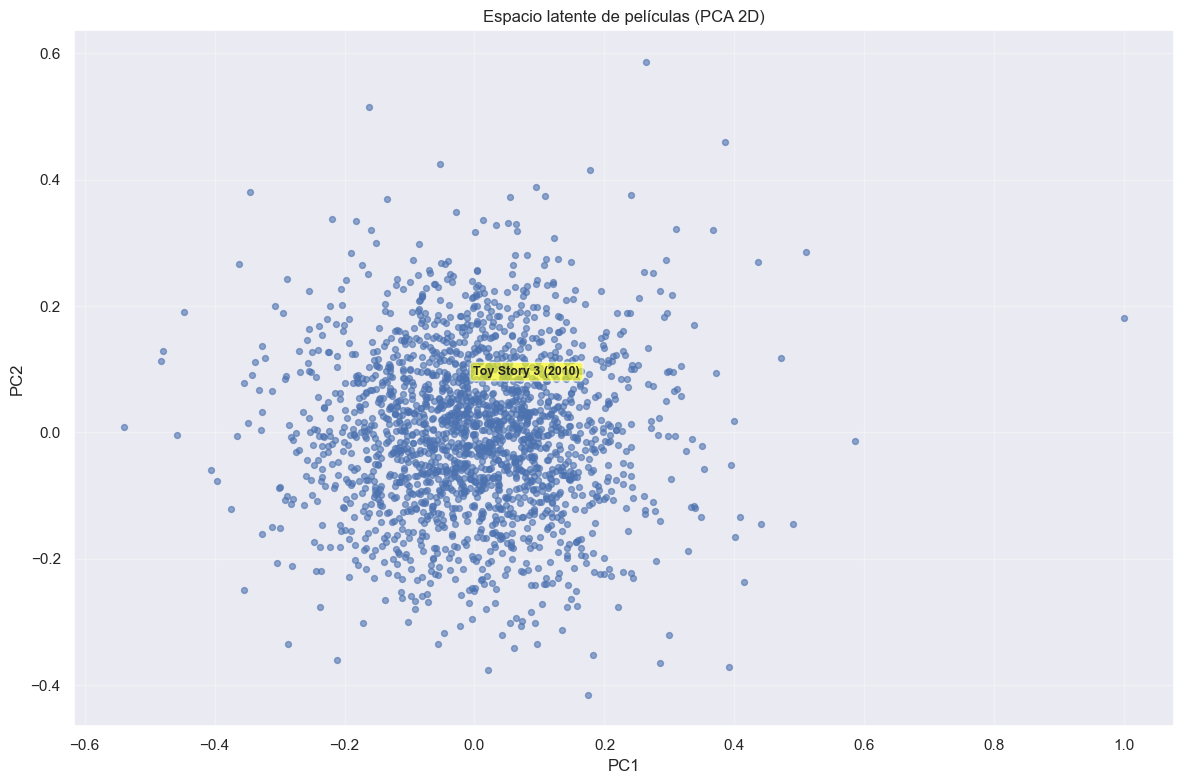

In [17]:
# 1) PCA con "Toy Story" anotado
plot_items_pca(
    movies_df=movies_df,          # debe tener ['movieId','title'] con movieId como str
    modelo=modelo,                # surprise.SVD ya entrenado con modelo.fit(trainset)
    trainset=trainset,            # Trainset usado en el fit
    highlight_titles=['Toy Story']# usa contains → también matchea "Toy Story (1995)"
)

5. **Utilizar alguna técnica de clustering para obtener grupos de usuarios similares que pueden ser interpretados como segmentos de clientes**

Agrupamos usuarios parecidos entre sí usando sus vectores latentes pᵤ del SVD y aplicamos K-Means (k=5) para formar segmentos. Luego describimos cada segmento con nº de ratings y nota media.

Con surprise.SVD, usando modelo.pu (usuarios) + trainset (mapeos). Comentado línea a línea (por qué) y listo para pegar.
1- Extraer user_vectors = modelo.pu y sus user_ids con trainset.to_raw_uid.
2.- KMeans(k=5) sobre user_vectors.
3.- Resumen por cluster (tamaño, nº ratings medio, nota media).
4.- PCA 2D para visualizar.


*K-Means busca k centros y asigna cada usuario al centro más cercano (distancia euclídea) para minimizar la inercia (suma de distancias cuadradas).
Resultado: etiqueta de cluster por usuario.

In [24]:
# Imports necasarios

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# KMeans agrupa datos en k clusters buscando k centroides y asignando cada punto al más cercano (distancia euclídea).
from sklearn.cluster import KMeans

#PCA (Principal Component Analysis) 
# reduce dimensiones encontrando ejes ortogonales que maximizan la varianza. 
# Sirve para resumir, des-ruido, y visualizar datos altos en 2D
from sklearn.decomposition import PCA

# El modelo ya lo he entrenado previamente.
# - 'modelo' es surprise.SVD ya entrenado con: trainset = data.build_full_trainset(); modelo.fit(trainset)
# - 'trainset' es el Trainset usado en el fit
# - 'ratings' es tu DataFrame original con columnas ['userId','movieId','rating'] (userId como str)



 RESUMEN DE CLUSTERS DE USUARIOS:
         user_count  rating_count  rating_mean
cluster                                       
0                84        93.607        3.610
1                53       565.264        3.304
2               187       135.155        3.669
3               101       145.426        3.704
4               185       124.605        3.742

 CLUSTERS :
Cluster 0: Usuarios moderados - rating promedio medio
  - Usuarios: 84
  - Ratings promedio por usuario: 93.6
  - Rating medio dado: 3.61
Cluster 1: Usuarios críticos - rating promedio bajo
  - Usuarios: 53
  - Ratings promedio por usuario: 565.3
  - Rating medio dado: 3.30
Cluster 2: Usuarios entusiastas - rating promedio alto
  - Usuarios: 187
  - Ratings promedio por usuario: 135.2
  - Rating medio dado: 3.67
Cluster 3: Usuarios ocasionales - baja actividad
  - Usuarios: 101
  - Ratings promedio por usuario: 145.4
  - Rating medio dado: 3.70
Cluster 4: Usuarios activos - alta actividad
  - Usuarios: 185
  - Ratin

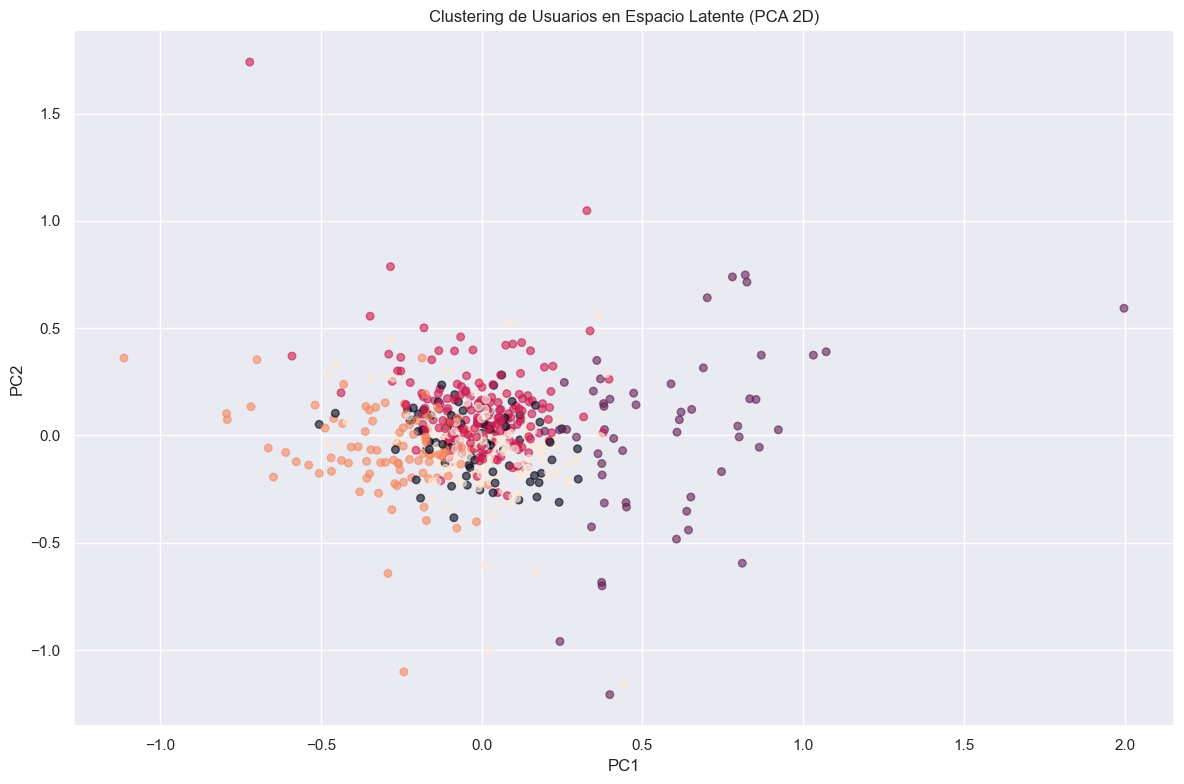

In [30]:

# CLUSTERING DE USUARIOS

# Vectores latentes de usuarios (pu) + ids raw ---
user_vectors = []   # acumulamos los valores de usuarios (p_u)
user_ids = []       # ids “raw” para manejar con ratings

#Recorremos todos los usuarios internos del trainset
for inner_u in range(trainset.n_users):                     # pu está indexado por ids internos 0..n_users-1
    raw_u = trainset.to_raw_uid(inner_u)                    # convertimos a id real (raw) para poder unir con ratings
    vec_u = modelo.pu[inner_u]                              # vector latente del usuario Pu (dimensión = n_factors), por defecto en el modelo SVD n_factors=100
    user_vectors.append(vec_u)
    user_ids.append(str(raw_u))                             # forzamos en str por consistencia con ratings['userId']

# Comprobación rápida
if len(user_vectors) == 0:
    print("No hay vectores de usuarios válidos para clustering")
else:
    user_vectors = np.asarray(user_vectors, dtype=float)    #  matriz (n_users × n_factors) para KMeans

    # Aplicar K-Means ---
    # Calculamos 5 clusters
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # why: n_init=10 estabiliza centros
    user_clusters = kmeans.fit_predict(user_vectors)           # etiquetas de cluster por usuario

    # DataFrame con asignaciones
    cluster_analysis = pd.DataFrame({
        "userId": user_ids,
        "cluster": user_clusters
    })

    # Métricas por usuario desde ratings (actividad y nota media)
    # Interpretar segmentos (críticos/entusiastas/ocasionales/activos)
    r = ratings.copy()
    r["userId"] = r["userId"].astype(str)                     # cambio tipo
    user_stats = (
        r.groupby("userId")["rating"] # agrupamos por usuario
         .agg(rating_count="count", rating_mean="mean") # Actividad y media
         .round(3) # redondeo 
         .reset_index() 
    )

    # Unir stats y resumir por cluster
    # .merge añade a cada usuario sus stats: rating_count y rating_mean
    # .filla si algún user no tenía stats, evita NaN en agregrados
    cluster_analysis = cluster_analysis.merge(user_stats, on="userId", how="left").fillna({"rating_count":0, "rating_mean":0.0})


    # agrupa todos los usuarios por su etiqueta de cluster
    cluster_summary = (
        cluster_analysis.groupby("cluster")
        # Agrupa todos los usuarios por su etiqueta de cluster
        #   - nº de usuarios en el cluster
        #   - promedio de ratings por usuario en el cluster
        #   - promedio de la nota media de los usuarios del cluster
        .agg(user_count=("userId","count"), rating_count=("rating_count","mean"), rating_mean=("rating_mean","mean"))
        .round(3)
    )

    print("\n RESUMEN DE CLUSTERS DE USUARIOS:")
    print(cluster_summary)

    # Interpretación
    print("\n CLUSTERS :")
    cluster_descriptions = {
        0: "Usuarios moderados - rating promedio medio",
        1: "Usuarios críticos - rating promedio bajo", 
        2: "Usuarios entusiastas - rating promedio alto",
        3: "Usuarios ocasionales - baja actividad",
        4: "Usuarios activos - alta actividad",
    }
    for c in sorted(cluster_summary.index):
        stats = cluster_summary.loc[c]
        desc = cluster_descriptions.get(int(c), "Cluster no definido")
        print(f"Cluster {c}: {desc}")
        print(f"  - Usuarios: {int(stats['user_count'])}")
        print(f"  - Ratings promedio por usuario: {stats['rating_count']:.1f}")
        print(f"  - Rating medio dado: {stats['rating_mean']:.2f}")

    # Visualización: PCA 2D de usuarios coloreados por cluster
   
    user_pca = PCA(n_components=2, random_state=42) #fija 2 componentes (máxima varianza) y reproducibilidad
    user_vectors_2d = user_pca.fit_transform(user_vectors) # reducir de k dimensiones a 2D

    plt.figure(figsize=(12, 8))                               # tamaño 
    plt.scatter(user_vectors_2d[:, 0], user_vectors_2d[:, 1], # cada punto = usuario en 2D
                c=user_clusters, alpha=0.6, s=30)             # color -> cluster (sin fijar cmap)
    
    plt.title("Clustering de Usuarios en Espacio Latente (PCA 2D)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout(); plt.show()

**Conclusiones**
<br>El SVD con CF funciona bien con ML-100K (Rating de peliculas), pero para recomendaciones más coherentes y explicables puede ser útil incorporar géneros (o más contenido).

Conclusiones (claras y al grano)

- CF puro (SVD) aprende gustos latentes y sesgos  𝑏𝑢 , 𝑏𝑖 solo con ratings → ya genera buenas predicciones y permite análisis (similares, clustering).
- Nuevos usuarios: reentrenar tras añadir sus ratings, para capturar sus preferencias reales.
- Sesgos: vimos usuarios “generosos/estrictos” y pelis con sesgo alto/bajo, la popularidad no siempre implica calidad.
- Clustering sobre  𝑝𝑢 produce segmentos interpretables (actividad y nota media).
- Limitaciones de CF puro: no usa género/año; su similitud es latente.